In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
start_date = "2015-01-01"
end_date = "2023-12-31"

In [116]:
universe = [
    "MMM",
    "AOS",
    "ABT",
    "ABBV",
    "ACN",
    "ADBE",
    "AMD",
    "AES",
    "AFL",
    "A",
    "APD",
    "ABNB",
    "AKAM",
    "ALB",
    "ARE",
    "ALGN",
    "ALLE",
    "LNT",
    "ALL",
    "GOOGL",
    "GOOG",
    "MO",
    "AMZN",
    "AMCR",
    "AEE",
    "AEP",
    "AXP",
    "AIG",
    "AMT",
    "AWK",
    "AMP",
    "AME",
    "AMGN",
    "APH",
    "ADI",
    "AON",
    "APA",
    "APO",
    "AAPL",
    "AMAT",
    "APP",
    "APTV",
    "ACGL",
    "ADM",
    "ARES",
    "ANET",
    "AJG",
    "AIZ",
    "T",
    "ATO",
    "ADSK",
    "ADP",
    "AZO",
    "AVB",
    "AVY",
    "AXON",
    "BKR",
    "BALL",
    "BAC",
    "BAX",
    "BDX",
    "BRK",
    "BBY",
    "TECH",
    "BIIB",
    "BLK",
    "BX",
    "XYZ",
    "BK",
    "BA",
    "BKNG",
    "BSX",
    "BMY",
    "AVGO",
    "BR",
    "BRO",
    "BF",
    "BLDR",
    "BG",
    "BXP",
    "CHRW",
    "CDNS",
    "CPT",
    "CPB",
    "COF",
    "CAH",
    "CCL",
    "CARR",
    "CVNA",
    "CASY",
    "CAT",
    "CBOE",
    "CBRE",
    "CDW",
    "COR",
    "CNC",
    "CNP",
    "CF",
    "CRL",
    "SCHW",
    "CHTR",
    "CVX",
    "CMG",
    "CB",
    "CHD",
    "CIEN",
    "CI",
    "CINF",
    "CTAS",
    "CSCO",
    "C",
    "CFG",
    "CLX",
    "CME",
    "CMS",
    "KO",
    "CTSH",
    "COHR",
    "COIN",
    "CL",
    "CMCSA",
    "FIX",
    "CAG",
    "COP",
    "ED",
    "STZ",
    "CEG",
    "COO",
    "CPRT",
    "GLW",
    "CPAY",
    "CTVA",
    "CSGP",
    "COST",
    "CTRA",
    "CRH",
    "CRWD",
    "CCI",
    "CSX",
    "CMI",
    "CVS",
    "DHR",
    "DRI",
    "DDOG",
    "DVA",
    "DECK",
    "DE",
    "DELL",
    "DAL",
    "DVN",
    "DXCM",
    "FANG",
    "DLR",
    "DG",
    "DLTR",
    "D",
    "DPZ",
    "DASH",
    "DOV",
    "DOW",
    "DHI",
    "DTE",
    "DUK",
    "DD",
    "ETN",
    "EBAY",
    "SATS",
    "ECL",
    "EIX",
    "EW",
    "EA",
    "ELV",
    "EME",
    "EMR",
    "ETR",
    "EOG",
    "EPAM",
    "EQT",
    "EFX",
    "EQIX",
    "EQR",
    "ERIE",
    "ESS",
    "EL",
    "EG",
    "EVRG",
    "ES",
    "EXC",
    "EXE",
    "EXPE",
    "EXPD",
    "EXR",
    "XOM",
    "FFIV",
    "FDS",
    "FICO",
    "FAST",
    "FRT",
    "FDX",
    "FIS",
    "FITB",
    "FSLR",
    "FE",
    "FISV",
    "F",
    "FTNT",
    "FTV",
    "FOXA",
    "FOX",
    "BEN",
    "FCX",
    "GRMN",
    "IT",
    "GE",
    "GEHC",
    "GEV",
    "GEN",
    "GNRC",
    "GD",
    "GIS",
    "GM",
    "GPC",
    "GILD",
    "GPN",
    "GL",
    "GDDY",
    "GS",
    "HAL",
    "HIG",
    "HAS",
    "HCA",
    "DOC",
    "HSIC",
    "HSY",
    "HPE",
    "HLT",
    "HD",
    "HON",
    "HRL",
    "HST",
    "HWM",
    "HPQ",
    "HUBB",
    "HUM",
    "HBAN",
    "HII",
    "IBM",
    "IEX",
    "IDXX",
    "ITW",
    "INCY",
    "IR",
    "PODD",
    "INTC",
    "IBKR",
    "ICE",
    "IFF",
    "IP",
    "INTU",
    "ISRG",
    "IVZ",
    "INVH",
    "IQV",
    "IRM",
    "JBHT",
    "JBL",
    "JKHY",
    "J",
    "JNJ",
    "JCI",
    "JPM",
    "KVUE",
    "KDP",
    "KEY",
    "KEYS",
    "KMB",
    "KIM",
    "KMI",
    "KKR",
    "KLAC",
    "KHC",
    "KR",
    "LHX",
    "LH",
    "LRCX",
    "LVS",
    "LDOS",
    "LEN",
    "LII",
    "LLY",
    "LIN",
    "LYV",
    "LMT",
    "L",
    "LOW",
    "LULU",
    "LITE",
    "LYB",
    "MTB",
    "MPC",
    "MAR",
    "MRSH",
    "MLM",
    "MAS",
    "MA",
    "MKC",
    "MCD",
    "MCK",
    "MDT",
    "MRK",
    "META",
    "MET",
    "MTD",
    "MGM",
    "MCHP",
    "MU",
    "MSFT",
    "MAA",
    "MRNA",
    "TAP",
    "MDLZ",
    "MPWR",
    "MNST",
    "MCO",
    "MS",
    "MOS",
    "MSI",
    "MSCI",
    "NDAQ",
    "NTAP",
    "NFLX",
    "NEM",
    "NWSA",
    "NWS",
    "NEE",
    "NKE",
    "NI",
    "NDSN",
    "NSC",
    "NTRS",
    "NOC",
    "NCLH",
    "NRG",
    "NUE",
    "NVDA",
    "NVR",
    "NXPI",
    "ORLY",
    "OXY",
    "ODFL",
    "OMC",
    "ON",
    "OKE",
    "ORCL",
    "OTIS",
    "PCAR",
    "PKG",
    "PLTR",
    "PANW",
    "PSKY",
    "PH",
    "PAYX",
    "PYPL",
    "PNR",
    "PEP",
    "PFE",
    "PCG",
    "PM",
    "PSX",
    "PNW",
    "PNC",
    "POOL",
    "PPG",
    "PPL",
    "PFG",
    "PG",
    "PGR",
    "PLD",
    "PRU",
    "PEG",
    "PTC",
    "PSA",
    "PHM",
    "PWR",
    "QCOM",
    "DGX",
    "Q",
    "RL",
    "RJF",
    "RTX",
    "O",
    "REG",
    "REGN",
    "RF",
    "RSG",
    "RMD",
    "RVTY",
    "HOOD",
    "ROK",
    "ROL",
    "ROP",
    "ROST",
    "RCL",
    "SPGI",
    "CRM",
    "SNDK",
    "SBAC",
    "SLB",
    "STX",
    "SRE",
    "NOW",
    "SHW",
    "SPG",
    "SWKS",
    "SJM",
    "SW",
    "SNA",
    "SOLV",
    "SO",
    "LUV",
    "SWK",
    "SBUX",
    "STT",
    "STLD",
    "STE",
    "SYK",
    "SMCI",
    "SYF",
    "SNPS",
    "SYY",
    "TMUS",
    "TROW",
    "TTWO",
    "TPR",
    "TRGP",
    "TGT",
    "TEL",
    "TDY",
    "TER",
    "TSLA",
    "TXN",
    "TPL",
    "TXT",
    "TMO",
    "TJX",
    "TKO",
    "TTD",
    "TSCO",
    "TT",
    "TDG",
    "TRV",
    "TRMB",
    "TFC",
    "TYL",
    "TSN",
    "USB",
    "UBER",
    "UDR",
    "ULTA",
    "UNP",
    "UAL",
    "UPS",
    "URI",
    "UNH",
    "UHS",
    "VLO",
    "VTR",
    "VLTO",
    "VRSN",
    "VRSK",
    "VZ",
    "VRTX",
    "VRT",
    "VTRS",
    "VICI",
    "V",
    "VST",
    "VMC",
    "WRB",
    "GWW",
    "WAB",
    "WMT",
    "DIS",
    "WBD",
    "WM",
    "WAT",
    "WEC",
    "WFC",
    "WELL",
    "WST",
    "WDC",
    "WY",
    "WSM",
    "WMB",
    "WTW",
    "WDAY",
    "WYNN",
    "XEL",
    "XYL",
    "YUM",
    "ZBRA",
    "ZBH",
    "ZTS",
]

In [117]:
data = yf.download(universe, start=start_date, end=end_date)

[**                     4%                       ]  21 of 503 completed$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[***                    6%                       ]  30 of 503 completed$BF: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[******                13%                       ]  64 of 503 completed$BRK: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31)
[*******************   40%                       ]  199 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[**********************82%**************         ]  414 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
[******

In [103]:
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
position_cnt = 25
asset_rank = 250
returns_df = close_df.pct_change().fillna(0)

## Momentum Strategy

In [104]:
mt_wind = 120
base_signal = returns_df.shift(5).rolling(mt_wind).mean().shift(1)

realized_vol = returns_df.rolling(40).std()
vol_thresh = realized_vol.rolling(70).quantile(0.75)

signal_df = base_signal.where(realized_vol.lt(vol_thresh, axis=0))

dollar_vol_df = (close_df * volume_df).dropna(axis=1)
avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
rank_mask = rank_df <= asset_rank

filtered_returns = returns_df.where(rank_mask)
filtered_signal_df = signal_df.where(rank_mask)

signal_rank = filtered_signal_df.rank(axis=1, ascending=False, na_option="bottom")

long = signal_rank <= position_cnt
short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
short = signal_rank.ge(short_cutoff.values[:, None])

positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

# NOTE: rebalance weekly
rebalance_mask = positions.index.to_series().dt.weekday == 0
positions_weekly = positions.where(rebalance_mask)
positions_weekly = positions_weekly.ffill()

pnl = positions_weekly.shift(1) * filtered_returns
port_ret_mom = pnl.sum(axis=1)
sharpe = port_ret_mom.mean() / port_ret_mom.std() * np.sqrt(252)
print(sharpe)

# cumulative equity curve
cum_ret = (1 + port_ret_mom).cumprod()
# running peak
running_max = cum_ret.cummax()
# drawdown series
drawdown_mom = cum_ret / running_max - 1
# max drawdown
max_dd_mom = drawdown_mom.min()

print("Max Drawdown:", max_dd_mom)

0.7030711229051998
Max Drawdown: -0.1459725964967752


<Axes: title={'center': 'Drawdown (Momentum)'}, xlabel='Date'>

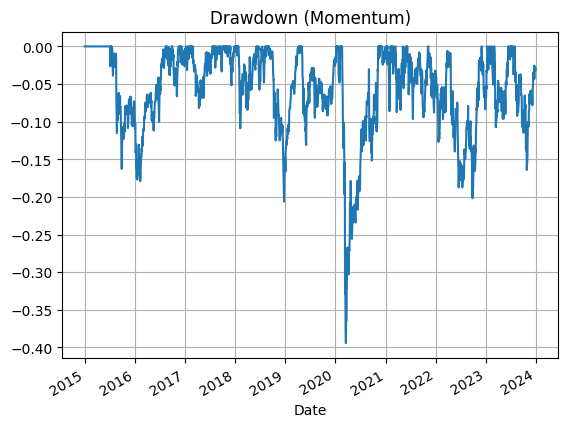

In [105]:
drawdown_mom.plot(title="Drawdown (Momentum)", grid=True)

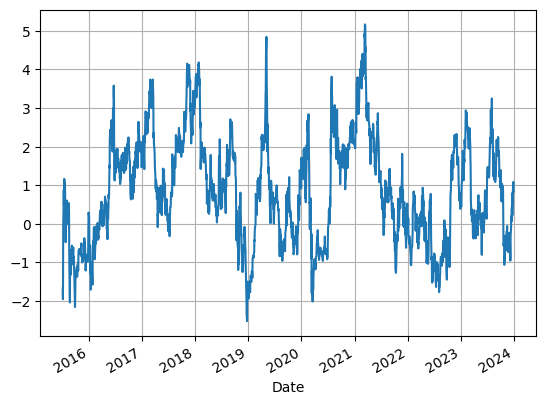

In [106]:
rolling_sharpe_mom = (port_ret_mom.rolling(90).mean() / port_ret_mom.rolling(90).std()) * np.sqrt(
    252
)

ax = rolling_sharpe_mom.plot(grid=True)

## Mean Reversion Strategy

In [107]:
# NOTE: signals
base_signal = -returns_df.rolling(5).mean().shift(1)

# NOTE: volume spike filter
volm_win = 10
volm_z = (volume_df - volume_df.rolling(volm_win).mean()) / volume_df.rolling(volm_win).std()

# NOTE: medium term momentum filter
long_mom = returns_df.rolling(15).mean()

signal_df = base_signal.where(
    volm_z.gt(volm_z.quantile(0.65, axis=1), axis=0)
    & long_mom.abs().lt(long_mom.quantile(0.75, axis=1), axis=0)
)

dollar_vol_df = (close_df * volume_df).dropna(axis=1)
avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
rank_mask = rank_df <= asset_rank

filtered_returns = returns_df.where(rank_mask)
filtered_signal_df = signal_df.where(rank_mask)

signal_rank = filtered_signal_df.rank(axis=1, ascending=False, na_option="bottom")

long = signal_rank <= position_cnt
short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
short = signal_rank.ge(short_cutoff.values[:, None])

positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

pnl = positions.shift(1) * filtered_returns
port_ret_mr = pnl.sum(axis=1)
sharpe = port_ret_mr.mean() / port_ret_mr.std() * np.sqrt(252)
print(sharpe)

# cumulative equity curve
cum_ret = (1 + port_ret_mr).cumprod()
# running peak
running_max = cum_ret.cummax()
# drawdown series
drawdown_mr = cum_ret / running_max - 1
# max drawdown
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)

1.0555732962426128
Max Drawdown: -0.1459725964967752


<Axes: title={'center': 'Drawdown (Momentum)'}, xlabel='Date'>

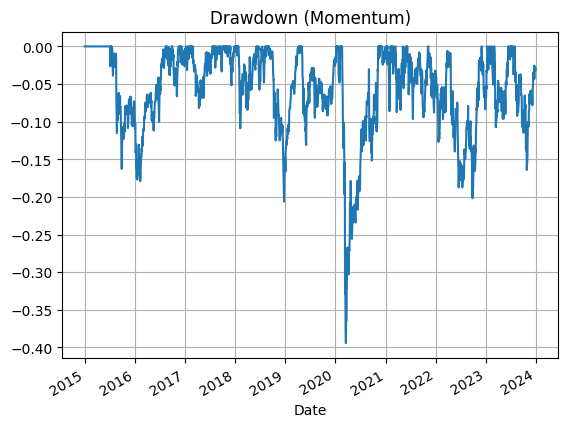

In [108]:
drawdown_mom.plot(title="Drawdown (Momentum)", grid=True)

<Axes: title={'center': 'Drawdown (Mean Reversion)'}, xlabel='Date'>

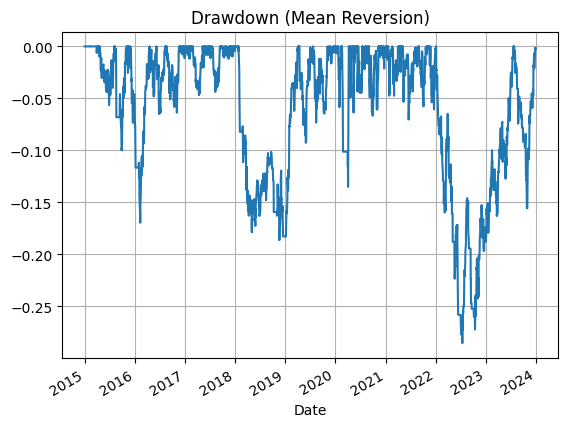

In [109]:
drawdown_mr.plot(title="Drawdown (Mean Reversion)", grid=True)

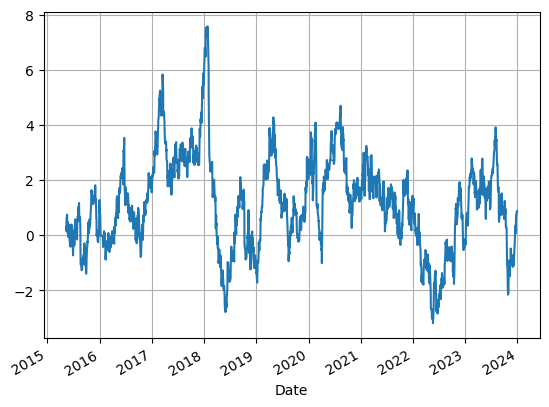

In [112]:
rolling_sharpe_mr = (port_ret_mr.rolling(90).mean() / port_ret_mr.rolling(90).std()) * np.sqrt(252)

ax = rolling_sharpe_mr.plot(grid=True)

## Residual Mean Reversion

In [118]:
market_universe = ["SPY", "XLK"]
market_data = yf.download(market_universe, start=start_date, end=end_date)

[*********************100%***********************]  2 of 2 completed


In [119]:
market_close = market_data["Close"]
factor_returns = market_close.pct_change().dropna()
factor_returns.columns = market_universe

In [120]:
common_index = returns_df.index.intersection(factor_returns.index)
returns_df = returns_df.loc[common_index]
factor_returns = factor_returns.loc[common_index]

In [121]:
X = sm.add_constant(factor_returns)
residuals_df = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)

for ticker in returns_df.columns:
    Y = returns_df[ticker]
    model = sm.OLS(Y, X, missing="drop").fit()
    residuals_df[ticker] = model.resid

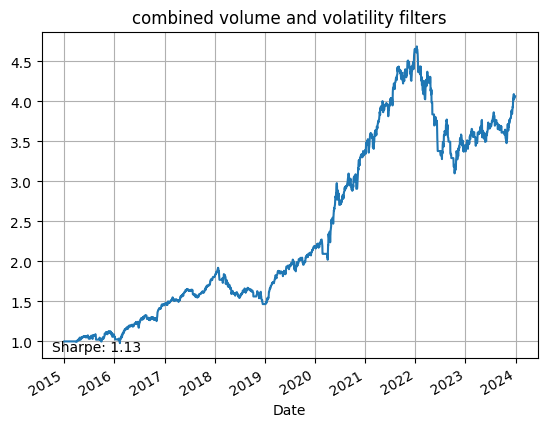

Max Drawdown: -0.33853360324945625


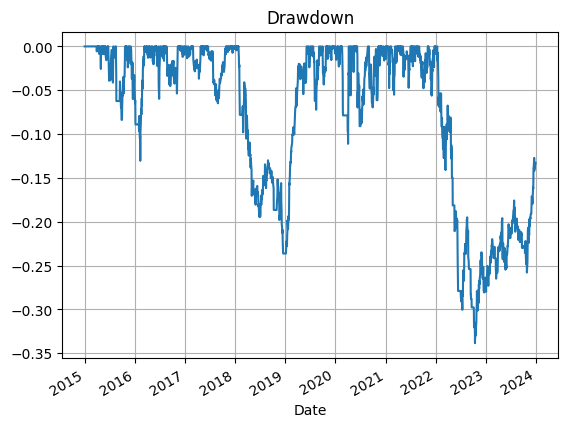

In [124]:
base_signal_df = -residuals_df.rolling(5).mean().shift(1)
base_signal_df = base_signal_df.sub(signal_df.mean(axis=1), axis=0)

realized_vol = residuals_df.rolling(5).std()
vol_z = (volume_df - volume_df.rolling(30).mean()) / volume_df.rolling(30).std()

signal_df = base_signal_df.where(
    (realized_vol.lt(realized_vol.quantile(0.6, axis=1), axis=0))
    & (vol_z.gt(vol_z.quantile(0.8, axis=1), axis=0))
)

dollar_vol_df = (close_df * volume_df).dropna(axis=1)
avg_dollar_vol_df = dollar_vol_df.rolling(60).mean()

rank_df = avg_dollar_vol_df.rank(axis=1, ascending=False)
rank_mask = rank_df <= asset_rank

filtered_returns = returns_df.where(rank_mask)
filtered_signal_df = signal_df.where(rank_mask)

signal_rank = filtered_signal_df.rank(axis=1, ascending=False, na_option="bottom")

long = signal_rank <= position_cnt
short_cutoff = signal_rank.count(axis=1) - (position_cnt - 1)
short = signal_rank.ge(short_cutoff.values[:, None])

positions = long.astype(int) - short.astype(int)
positions = positions.div(positions.abs().sum(axis=1), axis=0)

pnl = positions.shift(1) * filtered_returns
port_ret_resd_mr = pnl.sum(axis=1)
sharpe = port_ret_resd_mr.mean() / port_ret_resd_mr.std() * np.sqrt(252)

cum_pnl = (1 + port_ret_resd_mr).cumprod()

ax = cum_pnl.plot(grid=True, title=f"combined volume and volatility filters")

plt.text(0.02, 0.02, f"Sharpe: {sharpe:.2f}", transform=ax.transAxes)
plt.show()

# cumulative equity curve
cum_ret = (1 + port_ret_resd_mr).cumprod()
# running peak
running_max = cum_ret.cummax()
# drawdown series
drawdown = cum_ret / running_max - 1
# max drawdown
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)
drawdown.plot(title="Drawdown", grid=True)
plt.show()

## Combined

In [126]:
port_ret_resd_mr.align(port_ret_mr)
corr = port_ret_resd_mr.corr(port_ret_mr)
print(corr)

0.8230155223497383


In [127]:
port_ret_resd_mr.align(port_ret_mom)
corr = port_ret_resd_mr.corr(port_ret_mom)
print(corr)

0.5588575904459661


In [113]:
port_ret_mom.align(port_ret_mr)
corr = port_ret_mom.corr(port_ret_mr)
print(corr)

0.5690072330380282


In [96]:
port_ret_mom.corr(port_ret_mr)

np.float64(0.5640266640772563)

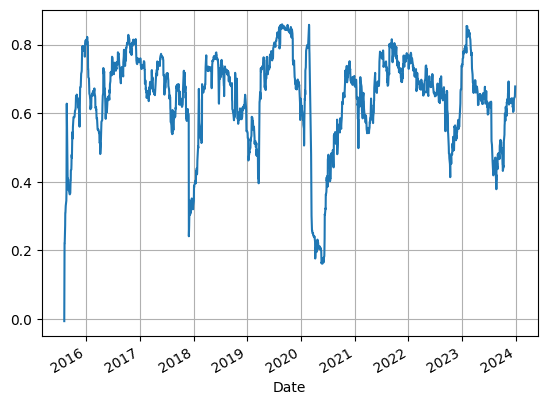

In [97]:
ax = port_ret_mom.rolling(60).corr(port_ret_mr).plot(grid=True)

In [98]:
drawdown_mom.corr(drawdown_mr)

np.float64(0.5827439829898783)

<Axes: title={'center': 'drawdown correlation'}, xlabel='Date'>

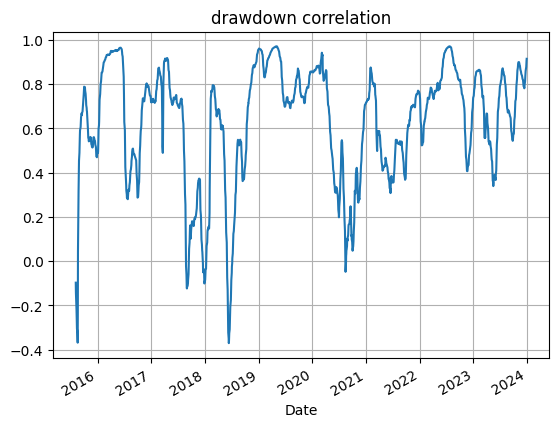

In [99]:
drawdown_mom.rolling(90).corr(drawdown_mr).plot(title="drawdown correlation", grid=True)

In [101]:
mom, mr = port_ret_mom.align(port_ret_mr)
combined = 0.5 * mom + 0.5 * mr
sharpe = combined.mean() / combined.std() * np.sqrt(252)

print(sharpe)

1.0143133016394394
